# Baseline — Block bootstrap multivariante condicionado

Baseline no paramétrico condicionado para generar trayectorias conjuntas de retornos BTC–ETH de 30 días remuestreando **bloques temporales completos**, nunca observaciones o activos por separado.

Para que la comparación sea justa, recibe exactamente el mismo vector normalizado de 14 variables de mercado que CVAE, Normalizing Flow y GAN. La condición restringe el remuestreo a estados históricos próximos; el modelo sigue siendo transparente y reproducible.

## Decisiones metodológicas

- Solo se ajusta con `train_sample_ids`; validación selecciona hiperparámetros y test se reserva para la evaluación final.
- Cada muestra de train aporta el bloque que comienza en su primer paso objetivo y su condición previa alineada. Como los inicios avanzan con stride 1, cada inicio candidato aparece una sola vez.
- Se usan las mismas 14 condiciones normalizadas con estadísticos de train que reciben los modelos generativos.
- Cada bloque conserva conjuntamente `[retorno_BTC, retorno_ETH]`.
- Ningún bloque puede atravesar huecos o velas truncadas.
- La trayectoria objetivo tiene 120 pasos de 6 horas.
- La longitud del bloque y el número de vecinos condicionantes se seleccionan conjuntamente con validación, nunca con prueba.
- Todos los bloques de una trayectoria se condicionan al estado inicial. No modelamos una transición dinámica del régimen tras cada bloque; esta limitación se tendrá en cuenta al interpretar los resultados.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
SOURCE_ROOT = PROJECT_ROOT / 'src'
if str(SOURCE_ROOT) not in sys.path:
    sys.path.insert(0, str(SOURCE_ROOT))

from crypto_generative.evaluation import (
    CrossAssetDependenceConfig,
    DiversityMemorizationConfig,
    RiskMetricsConfig,
    TemporalDependenceConfig,
    TrajectoryEvaluator,
    TrajectoryMetricsConfig,
)
from crypto_generative.models import (
    FROZEN_CONDITIONAL_BLOCK_LENGTH,
    FROZEN_CONDITIONAL_NEIGHBORS,
    ConditionalMultivariateBlockBootstrap,
)

SEED = 42
INTERVAL_HOURS = 6
HORIZON_STEPS = 120  # 30 días
PROVISIONAL_BLOCK_LENGTH = 20  # 5 días; todavía no está congelado
PROVISIONAL_NEIGHBORS = 128
N_SCENARIOS = 2_000

PANEL_PATH = PROJECT_ROOT / 'data/processed/binance/btc_eth_6h_panel.csv'
NORMALIZED_PATH = (
    PROJECT_ROOT
    / 'data/normalized/binance/btc_eth_6h_c240_t120_train_normalized.npz'
)
SPLIT_INDEX_PATH = (
    PROJECT_ROOT
    / 'data/splits/binance/btc_eth_6h_c240_t120_purged_split_index.csv'
)

assert PANEL_PATH.exists(), f'No existe {PANEL_PATH}'
assert NORMALIZED_PATH.exists(), f'No existe {NORMALIZED_PATH}'
assert SPLIT_INDEX_PATH.exists(), f'No existe {SPLIT_INDEX_PATH}'

## 1. Cargar el panel y el split congelado

El panel limpio está versionado en Git. El índice del split determina las particiones temporales purgadas y el NPZ normalizado contiene trayectorias y condiciones alineadas. Solo train se usa para construir el banco de bloques.

In [2]:
panel = pd.read_csv(PANEL_PATH)
split_index = pd.read_csv(SPLIT_INDEX_PATH)

panel_datetime_columns = ['open_time_utc', 'expected_close_time_utc']
split_datetime_columns = [
    'condition_start_utc',
    'condition_end_utc',
    'target_start_utc',
    'target_end_utc',
]
for column in panel_datetime_columns:
    panel[column] = pd.to_datetime(panel[column], utc=True)
for column in split_datetime_columns:
    split_index[column] = pd.to_datetime(split_index[column], utc=True)

train_index = split_index.loc[split_index['split'].eq('train')].copy()
assert len(train_index) == 4_710, (
    f'Se esperaban 4.710 muestras train y se encontraron {len(train_index):,}'
)

with np.load(NORMALIZED_PATH, allow_pickle=False) as normalized:
    stored_sample_ids = normalized['sample_ids'].astype(np.int64)
    normalized_targets = normalized['target_returns'].astype(np.float64)
    normalized_conditions = normalized['condition_features'].astype(np.float64)
    condition_feature_names = normalized['feature_names'].astype(str)
    return_mean = normalized['return_mean'].astype(np.float64)
    return_scale = normalized['return_scale'].astype(np.float64)

id_to_position = pd.Series(
    np.arange(len(stored_sample_ids)),
    index=stored_sample_ids,
)

def load_conditioned_targets(sample_ids: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Devuelve objetivos originales y condiciones normalizadas por ID."""
    positions = id_to_position.loc[sample_ids].to_numpy()
    targets = (
        normalized_targets[positions] * return_scale + return_mean
    )
    return targets, normalized_conditions[positions]

training_ids = train_index['sample_id'].to_numpy(dtype=np.int64)
training_targets, train_conditions = load_conditioned_targets(training_ids)
assert training_targets.shape == (4_710, HORIZON_STEPS, 2)
assert train_conditions.shape == (4_710, 14)

print(f'Filas del panel: {len(panel):,}')
print(f'Muestras train: {len(train_index):,}')
print(f'Variables condicionantes: {len(condition_feature_names)}')
print(
    'Cobertura de objetivos train:',
    train_index['target_start_utc'].min(),
    '→',
    train_index['target_end_utc'].max(),
)

Filas del panel: 13,081
Muestras train: 4,710
Variables condicionantes: 14
Cobertura de objetivos train: 2017-11-06 00:00:00+00:00 → 2023-07-30 12:00:00+00:00


## 2. Reconstruir retornos únicos de entrenamiento

Una muestra del dataset comparte la mayoría de sus retornos con muestras vecinas. Concatenar las 4.710 trayectorias de entrenamiento multiplicaría artificialmente el peso de las mismas fechas.

Aquí marcamos la **unión temporal** de todos los intervalos de entrenamiento y calculamos cada retorno una sola vez. La validez exige dos velas consecutivas completas y separadas exactamente seis horas.

In [3]:
panel = panel.sort_values('open_time_utc').reset_index(drop=True)
expected_delta = pd.Timedelta(hours=INTERVAL_HOURS)
regular_step = panel['open_time_utc'].diff().eq(expected_delta)
current_complete = panel['is_complete'].eq(1)
previous_complete = current_complete.shift(1, fill_value=False)
panel['returns_valid'] = regular_step & current_complete & previous_complete

for asset in ('btc', 'eth'):
    panel[f'{asset}_log_return'] = np.log(panel[f'{asset}_close']).diff()

def interval_union_mask(
    intervals: pd.DataFrame,
    start_column: str,
    end_column: str,
    timestamp_index: pd.DatetimeIndex,
) -> np.ndarray:
    """Máscara de la unión de intervalos cerrados sobre el panel UTC."""
    coverage_delta = np.zeros(len(timestamp_index) + 1, dtype=np.int64)
    for row in intervals.itertuples(index=False):
        start_time = getattr(row, start_column)
        end_time = getattr(row, end_column)
        start = timestamp_index.searchsorted(start_time, side='left')
        stop = timestamp_index.searchsorted(end_time, side='right')
        if start == stop or start == len(timestamp_index):
            raise RuntimeError(f'Intervalo fuera del panel: {start_time} → {end_time}')
        coverage_delta[start] += 1
        coverage_delta[stop] -= 1
    return np.cumsum(coverage_delta[:-1]) > 0


# La unión evita contar muchas veces el mismo retorno por el solapamiento.
timestamp_index = pd.DatetimeIndex(panel['open_time_utc'])
covered_by_train = interval_union_mask(
    train_index,
    'condition_start_utc',
    'target_end_utc',
    timestamp_index,
)
assert panel.loc[covered_by_train, 'returns_valid'].all(), (
    'Una ventana train contiene retornos no válidos; revisar el pipeline.'
)

train_returns = panel.loc[
    covered_by_train,
    ['open_time_utc', 'btc_log_return', 'eth_log_return'],
].copy()

# Un nuevo segmento comienza cuando entre retornos cubiertos hay más de 6 horas.
train_returns['segment_id'] = (
    train_returns['open_time_utc'].diff().ne(expected_delta).cumsum()
)
segment_lengths = train_returns.groupby('segment_id').size()

print(f'Retornos temporales únicos de train: {len(train_returns):,}')
print(f'Segmentos contiguos: {len(segment_lengths)}')
print('Longitudes por segmento:', segment_lengths.to_list())
assert len(train_returns) == 8_300

Retornos temporales únicos de train: 8,300
Segmentos contiguos: 10
Longitudes por segmento: [616, 546, 530, 470, 365, 751, 1223, 496, 438, 2865]


## 3. Dependencia temporal y longitud del bloque

Los retornos suelen presentar poca autocorrelación lineal, pero sus valores absolutos mantienen dependencia por el agrupamiento de volatilidad. Un bloque de longitud 1 destruiría esta información.

La gráfica siguiente es diagnóstica. El valor provisional de 20 pasos (5 días) no se elegirá definitivamente hasta comparar varias longitudes sobre validación.

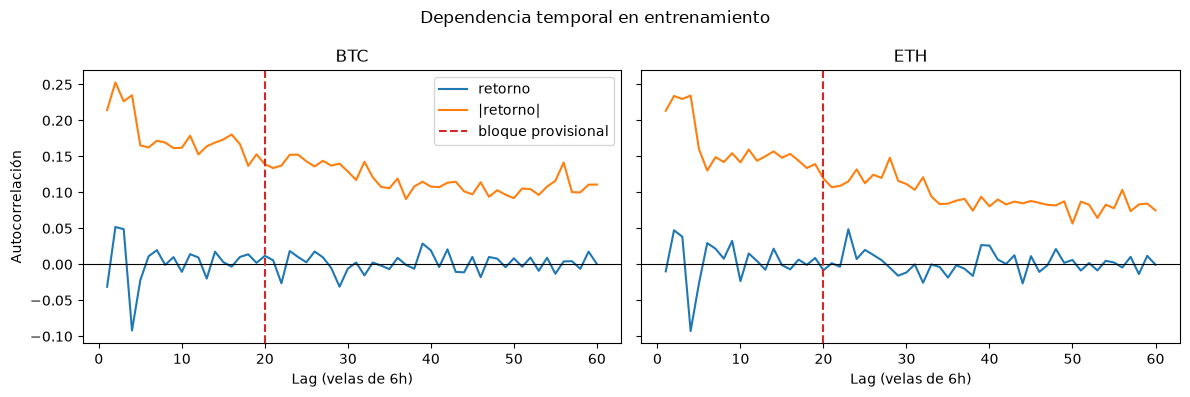

In [4]:
def segmented_autocorrelation(
    values: np.ndarray,
    segment_ids: np.ndarray,
    max_lag: int,
) -> np.ndarray:
    """ACF que excluye todos los pares situados a ambos lados de un hueco."""
    centered = values - values.mean()
    denominator = np.dot(centered, centered)
    correlations = []
    for lag in range(1, max_lag + 1):
        same_segment = segment_ids[:-lag] == segment_ids[lag:]
        numerator = np.dot(
            centered[:-lag][same_segment],
            centered[lag:][same_segment],
        )
        correlations.append(numerator / denominator)
    return np.asarray(correlations)

max_lag = 60
lags = np.arange(1, max_lag + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
segment_ids = train_returns['segment_id'].to_numpy()
for axis, asset in zip(axes, ('btc', 'eth')):
    values = train_returns[f'{asset}_log_return'].to_numpy()
    axis.plot(
        lags,
        segmented_autocorrelation(values, segment_ids, max_lag),
        label='retorno',
    )
    axis.plot(
        lags,
        segmented_autocorrelation(np.abs(values), segment_ids, max_lag),
        label='|retorno|',
    )
    axis.axhline(0, color='black', linewidth=0.8)
    axis.axvline(PROVISIONAL_BLOCK_LENGTH, color='tab:red', linestyle='--', label='bloque provisional')
    axis.set(title=asset.upper(), xlabel='Lag (velas de 6h)')
axes[0].set_ylabel('Autocorrelación')
axes[0].legend()
fig.suptitle('Dependencia temporal en entrenamiento')
fig.tight_layout()

## 4. Implementación del sampler multivariante condicionado

Cada trayectoria de train aporta su bloque inicial, alineado con el estado de mercado inmediatamente anterior. Para una condición nueva calculamos distancia euclídea sobre las mismas 14 variables normalizadas y elegimos uniformemente entre los `k` vecinos más próximos. Repetimos el remuestreo hasta completar el horizonte.

Esta versión conserva dos limitaciones del *moving block bootstrap*: la unión entre bloques puede crear una discontinuidad y el régimen no se actualiza durante la trayectoria. Aun así, la distribución de salida sí depende explícitamente de la condición solicitada y usa el mismo conjunto de información que los generadores.

In [5]:
# La implementación reutilizable vive en crypto_generative.models.
# Este notebook conserva únicamente el uso didáctico del baseline.
print('Sampler común:', ConditionalMultivariateBlockBootstrap.__name__)

Sampler común: ConditionalMultivariateBlockBootstrap


In [6]:
return_columns = ['btc_log_return', 'eth_log_return']
bootstrap = ConditionalMultivariateBlockBootstrap(
    block_length=PROVISIONAL_BLOCK_LENGTH,
    n_neighbors=PROVISIONAL_NEIGHBORS,
    random_state=SEED,
).fit(
    training_targets,
    train_conditions,
)
provisional_rng = np.random.default_rng(SEED)
provisional_condition_indices = provisional_rng.integers(
    0, len(train_conditions), size=N_SCENARIOS
)
synthetic_conditions = train_conditions[provisional_condition_indices]
synthetic = bootstrap.sample(
    n_scenarios=N_SCENARIOS,
    cond=synthetic_conditions,
    horizon_steps=HORIZON_STEPS,
)

print(f'Bloques candidatos: {len(bootstrap.blocks):,}')
print(f'Vecinos por condición: {bootstrap.n_neighbors:,}')
print('Forma sintética:', synthetic.shape)
assert synthetic.shape == (N_SCENARIOS, HORIZON_STEPS, 2)

Bloques candidatos: 4,710
Vecinos por condición: 128
Forma sintética: (2000, 120, 2)


## 5. Sanity check mínimo

Todavía no es el evaluador definitivo. Solo comprobamos que media, volatilidad y correlación contemporánea sean razonables y que las trayectorias tengan diversidad. Las métricas finales se calcularán fuera de muestra y serán comunes a todos los modelos.

In [7]:
historical = train_returns[return_columns].to_numpy()
synthetic_flat = synthetic.reshape(-1, 2)

sanity = pd.DataFrame(
    {
        'histórico': [
            historical[:, 0].mean(),
            historical[:, 1].mean(),
            historical[:, 0].std(ddof=1),
            historical[:, 1].std(ddof=1),
            np.corrcoef(historical.T)[0, 1],
        ],
        'sintético': [
            synthetic_flat[:, 0].mean(),
            synthetic_flat[:, 1].mean(),
            synthetic_flat[:, 0].std(ddof=1),
            synthetic_flat[:, 1].std(ddof=1),
            np.corrcoef(synthetic_flat.T)[0, 1],
        ],
    },
    index=['media_BTC', 'media_ETH', 'vol_BTC', 'vol_ETH', 'corr_BTC_ETH'],
)
sanity

,histórico,sintético
media_BTC,0.000114,0.000124
media_ETH,0.000115,0.000255
vol_BTC,0.019969,0.017032
vol_ETH,0.024540,0.020736
corr_BTC_ETH,0.809180,0.762499


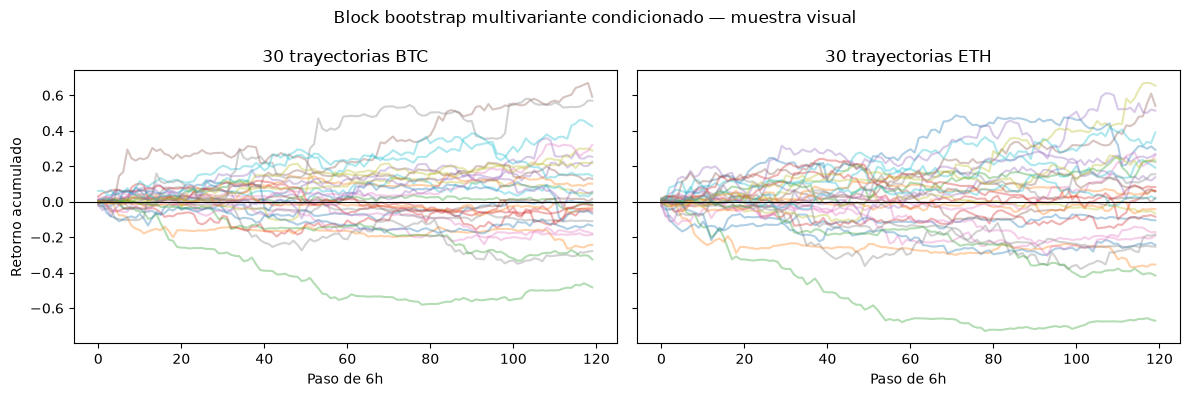

In [8]:
cumulative_simple_returns = np.exp(np.cumsum(synthetic, axis=1)) - 1
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for asset_index, (axis, asset) in enumerate(zip(axes, ('BTC', 'ETH'))):
    axis.plot(cumulative_simple_returns[:30, :, asset_index].T, alpha=0.35)
    axis.axhline(0, color='black', linewidth=0.8)
    axis.set(title=f'30 trayectorias {asset}', xlabel='Paso de 6h')
axes[0].set_ylabel('Retorno acumulado')
fig.suptitle('Block bootstrap multivariante condicionado — muestra visual')
fig.tight_layout()

## 6. Selección de longitud y vecindario con validación

Comparamos bloques entre 1 vela (control IID) y 120 velas (todo el horizonte), junto con varios tamaños de vecindario condicionante. El control de longitud 1 se informa, pero no puede ganar porque dejaría de ser un bootstrap de bloques. Cada sampler se **ajusta exclusivamente con trayectorias y condiciones de train**. Las condiciones de consulta proceden de validación y se muestrean de forma uniforme para representar su distribución de estados. Prueba queda completamente al margen.

No existe una única distancia perfecta, así que usamos cinco criterios complementarios: marginales, retorno acumulado a 30 días, volatilidad realizada, correlación BTC–ETH por trayectoria y autocorrelación de retornos absolutos. Como sus escalas son distintas, la decisión usa el rango medio de las métricas, todas con el mismo peso. Esta regla y la rejilla quedan fijadas antes de observar prueba.

In [9]:
validation_index = split_index.loc[split_index['split'].eq('validation')].copy()
validation_ids = validation_index['sample_id'].to_numpy(dtype=np.int64)
assert len(training_ids) == 4_710
assert len(validation_ids) == 1_832
# Se extraen únicamente train y validación; prueba permanece intacta.
validation_targets, validation_conditions = load_conditioned_targets(
    validation_ids
)

assert training_targets.shape == (4_710, HORIZON_STEPS, 2)
assert validation_targets.shape == (1_832, HORIZON_STEPS, 2)
assert validation_conditions.shape == (1_832, 14)
assert np.isfinite(training_targets).all()
assert np.isfinite(validation_targets).all()

# Para las marginales usamos la unión de objetivos: cada fecha valida pesa una vez.
covered_by_validation_target = interval_union_mask(
    validation_index,
    'target_start_utc',
    'target_end_utc',
    timestamp_index,
)
assert panel.loc[covered_by_validation_target, 'returns_valid'].all()
validation_unique_returns = panel.loc[
    covered_by_validation_target,
    return_columns,
].to_numpy()

print(f'Trayectorias de validación: {len(validation_targets):,}')
print(f'Retornos objetivo únicos de validación: {len(validation_unique_returns):,}')
print('Prueba consultada: no')

Trayectorias de validación: 1,832
Retornos objetivo únicos de validación: 1,951
Prueba consultada: no


### Métricas de selección

La distancia de Wasserstein se aproxima comparando cuantiles empíricos. La normalizamos por la desviación típica de la referencia cuando la unidad de medida lo requiere. La ACF se calcula dentro de cada trayectoria: nunca se crean pares artificiales entre el final de una trayectoria y el comienzo de otra.

In [10]:
def normalized_quantile_distance(
    reference: np.ndarray,
    candidate: np.ndarray,
    *,
    normalize: bool = True,
    n_quantiles: int = 1_001,
) -> float:
    """Wasserstein-1 empírica aproximada, opcionalmente sin unidades."""
    reference = np.asarray(reference, dtype=np.float64).ravel()
    candidate = np.asarray(candidate, dtype=np.float64).ravel()
    if not (np.isfinite(reference).all() and np.isfinite(candidate).all()):
        raise ValueError('La distancia recibió valores no finitos')
    probabilities = np.linspace(0.0, 1.0, n_quantiles)
    distance = np.mean(
        np.abs(
            np.quantile(reference, probabilities)
            - np.quantile(candidate, probabilities)
        )
    )
    if not normalize:
        return float(distance)
    scale = reference.std(ddof=1)
    if scale <= 0:
        raise ValueError('La referencia tiene escala nula')
    return float(distance / scale)


def path_statistics(paths: np.ndarray) -> dict[str, np.ndarray]:
    """Estadísticos por trayectoria, sin mezclar observaciones entre paths."""
    paths = np.asarray(paths, dtype=np.float64)
    if paths.ndim != 3 or paths.shape[-1] != 2:
        raise ValueError('paths debe tener forma [trayectorias, tiempo, 2]')
    centered = paths - paths.mean(axis=1, keepdims=True)
    standard_deviation = paths.std(axis=1, ddof=1)
    covariance = np.sum(centered[:, :, 0] * centered[:, :, 1], axis=1)
    covariance /= paths.shape[1] - 1
    correlation = covariance / (
        standard_deviation[:, 0] * standard_deviation[:, 1]
    )
    return {
        'cumulative_log_return': paths.sum(axis=1),
        'annualized_volatility': standard_deviation * np.sqrt(4 * 365),
        'correlation': correlation,
    }


def pooled_absolute_return_acf(paths: np.ndarray, max_lag: int = 20) -> np.ndarray:
    """ACF agrupada por activo que respeta los límites de cada trayectoria."""
    absolute_returns = np.abs(np.asarray(paths, dtype=np.float64))
    centered = absolute_returns - absolute_returns.mean(
        axis=(0, 1),
        keepdims=True,
    )
    correlations = []
    for lag in range(1, max_lag + 1):
        left = centered[:, :-lag, :]
        right = centered[:, lag:, :]
        numerator = np.sum(left * right, axis=(0, 1))
        denominator = np.sqrt(
            np.sum(left**2, axis=(0, 1))
            * np.sum(right**2, axis=(0, 1))
        )
        correlations.append(numerator / denominator)
    return np.asarray(correlations)


validation_statistics = path_statistics(validation_targets)
validation_absolute_acf = pooled_absolute_return_acf(validation_targets)

In [11]:
BLOCK_LENGTHS = [1, 4, 12, 20, 40, 60, 120]
NEIGHBOR_COUNTS = [32, 64, 128, 256]
SELECTION_SCENARIOS = len(validation_conditions)
METRIC_COLUMNS = [
    'marginal_return_w1',
    'cumulative_return_w1',
    'realized_volatility_w1',
    'path_correlation_w1',
    'absolute_return_acf_rmse',
]

def evaluate_paths_against_validation(candidate_paths: np.ndarray) -> dict[str, float]:
    """Aplica exactamente los cinco criterios fijados para validación."""
    candidate_statistics = path_statistics(candidate_paths)
    candidate_absolute_acf = pooled_absolute_return_acf(candidate_paths)
    return {
        'marginal_return_w1': np.mean([
            normalized_quantile_distance(
                validation_unique_returns[:, asset],
                candidate_paths[:, :, asset],
            )
            for asset in range(2)
        ]),
        'cumulative_return_w1': np.mean([
            normalized_quantile_distance(
                validation_statistics['cumulative_log_return'][:, asset],
                candidate_statistics['cumulative_log_return'][:, asset],
            )
            for asset in range(2)
        ]),
        'realized_volatility_w1': np.mean([
            normalized_quantile_distance(
                validation_statistics['annualized_volatility'][:, asset],
                candidate_statistics['annualized_volatility'][:, asset],
            )
            for asset in range(2)
        ]),
        'path_correlation_w1': normalized_quantile_distance(
            validation_statistics['correlation'],
            candidate_statistics['correlation'],
            normalize=False,
        ),
        'absolute_return_acf_rmse': np.sqrt(
            np.mean((candidate_absolute_acf - validation_absolute_acf) ** 2)
        ),
    }


metric_rows = []

for block_length in BLOCK_LENGTHS:
    for n_neighbors in NEIGHBOR_COUNTS:
        candidate_sampler = ConditionalMultivariateBlockBootstrap(
            block_length=block_length,
            n_neighbors=n_neighbors,
            random_state=SEED + block_length + n_neighbors,
        ).fit(training_targets, train_conditions)
        # Una generación por cada estado de validación: no se mezcla con test.
        candidate_paths = candidate_sampler.sample(
            n_scenarios=SELECTION_SCENARIOS,
            cond=validation_conditions,
            horizon_steps=HORIZON_STEPS,
        )
        candidate_metrics = evaluate_paths_against_validation(candidate_paths)

        metric_rows.append({
            'block_length_steps': block_length,
            'block_length_days': block_length * INTERVAL_HOURS / 24,
            'n_neighbors': n_neighbors,
            'candidate_blocks': len(candidate_sampler.blocks),
            **candidate_metrics,
        })

selection_results = pd.DataFrame(metric_rows)
selection_results['eligible_as_block_bootstrap'] = (
    selection_results['block_length_steps'] > 1
)
rank_columns = []
for metric in METRIC_COLUMNS:
    rank_column = f'{metric}_rank'
    selection_results[rank_column] = np.nan
    eligible = selection_results['eligible_as_block_bootstrap']
    selection_results.loc[eligible, rank_column] = (
        selection_results.loc[eligible, metric].rank(
            method='average',
            ascending=True,
        )
    )
    rank_columns.append(rank_column)
selection_results['mean_rank'] = selection_results[rank_columns].mean(axis=1)
selection_results = selection_results.sort_values(
    ['mean_rank', 'block_length_steps', 'n_neighbors'],
).reset_index(drop=True)
SELECTED_BLOCK_LENGTH = int(selection_results.loc[0, 'block_length_steps'])
SELECTED_NEIGHBORS = int(selection_results.loc[0, 'n_neighbors'])
assert SELECTED_BLOCK_LENGTH == FROZEN_CONDITIONAL_BLOCK_LENGTH
assert SELECTED_NEIGHBORS == FROZEN_CONDITIONAL_NEIGHBORS

display_columns = [
    'block_length_steps',
    'block_length_days',
    'n_neighbors',
    'eligible_as_block_bootstrap',
    'candidate_blocks',
    *METRIC_COLUMNS,
    'mean_rank',
]
selection_results[display_columns].style.format(precision=4)

,block_length_steps,block_length_days,n_neighbors,eligible_as_block_bootstrap,candidate_blocks,marginal_return_w1,cumulative_return_w1,realized_volatility_w1,path_correlation_w1,absolute_return_acf_rmse,mean_rank
0,12,3.0000,128,True,4710,0.0549,0.2904,0.1658,0.0481,0.0350,4.4000
1,4,1.0000,128,True,4710,0.0528,0.2921,0.2250,0.0435,0.0409,4.6000
2,4,1.0000,256,True,4710,0.0550,0.2732,0.1935,0.0445,0.0418,5.0000
3,20,5.0000,128,True,4710,0.0576,0.2929,0.1436,0.0493,0.0372,5.4000
4,12,3.0000,256,True,4710,0.0576,0.2953,0.1630,0.0505,0.0337,6.4000
5,20,5.0000,64,True,4710,0.0541,0.3306,0.2012,0.0501,0.0403,7.8000
6,20,5.0000,256,True,4710,0.0626,0.3342,0.1597,0.0517,0.0356,8.8000
7,4,1.0000,64,True,4710,0.0525,0.4175,0.2619,0.0451,0.0426,9.6000
8,12,3.0000,64,True,4710,0.0534,0.3623,0.2168,0.0520,0.0395,10.0000
9,40,10.0000,64,True,4710,0.0658,0.3265,0.2421,0.0490,0.0497,10.4000


Configuración seleccionada: 12 pasos de 6h (3 días), 128 vecinos.
Conjunto de prueba consultado durante la selección: no.


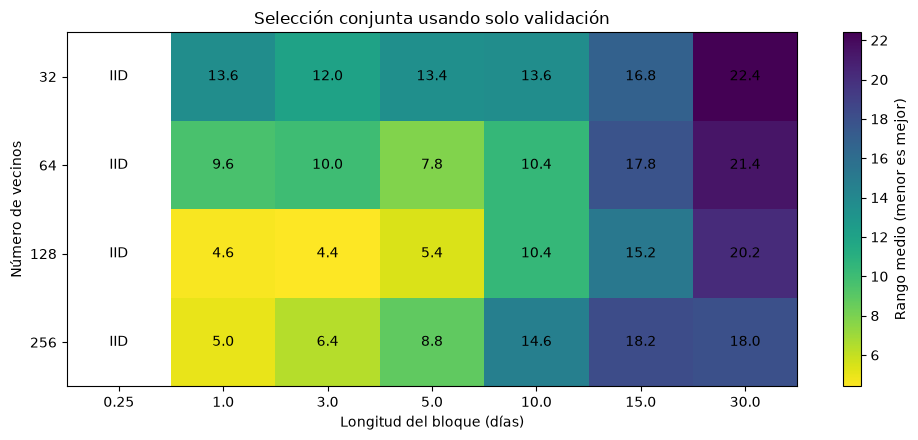

In [12]:
rank_surface = selection_results.pivot(
    index='n_neighbors',
    columns='block_length_days',
    values='mean_rank',
).sort_index().sort_index(axis=1)
fig, axis = plt.subplots(figsize=(10, 4.5))
image = axis.imshow(rank_surface, aspect='auto', cmap='viridis_r')
axis.set_xticks(np.arange(rank_surface.shape[1]), rank_surface.columns)
axis.set_yticks(np.arange(rank_surface.shape[0]), rank_surface.index)
axis.set(
    title='Selección conjunta usando solo validación',
    xlabel='Longitud del bloque (días)',
    ylabel='Número de vecinos',
)
for row in range(rank_surface.shape[0]):
    for column in range(rank_surface.shape[1]):
        value = rank_surface.iloc[row, column]
        axis.text(
            column, row, f'{value:.1f}' if np.isfinite(value) else 'IID',
            ha='center', va='center', color='black',
        )
fig.colorbar(image, ax=axis, label='Rango medio (menor es mejor)')
fig.tight_layout()

selected_days = SELECTED_BLOCK_LENGTH * INTERVAL_HOURS / 24
print(
    f'Configuración seleccionada: {SELECTED_BLOCK_LENGTH} pasos de 6h '
    f'({selected_days:g} días), {SELECTED_NEIGHBORS} vecinos.'
)
print('Conjunto de prueba consultado durante la selección: no.')

### Resultado e interpretación

La primera fila de `selection_results` fija conjuntamente la longitud y el vecindario. La opción elegida logra el mejor equilibrio entre los cinco criterios, no necesariamente el mínimo en cada uno por separado. Los resultados deben interpretarse después de ejecutar la rejilla; no conservamos cifras del baseline incondicional.

Un vecindario pequeño condiciona con mayor precisión pero eleva la varianza y la memorización; uno grande aporta diversidad a costa de diluir el régimen. La selección por validación hace explícito ese compromiso. **Prueba no se usa ni para calcular las métricas ni para desempatar.**

## 7. Aplicar el evaluador común

Congelamos la longitud y el número de vecinos elegidos y generamos un lote nuevo condicionado a estados de **test**. Solo después de congelar ambos hiperparámetros consultamos los objetivos de test y usamos el mismo `TrajectoryEvaluator` que los modelos generativos. Tanto la referencia como el candidato están en retornos logarítmicos originales.

In [13]:
test_index = split_index.loc[split_index['split'].eq('test')].copy()
test_ids = test_index['sample_id'].to_numpy(dtype=np.int64)
assert len(test_ids) == 1_826
test_targets, test_conditions = load_conditioned_targets(test_ids)
assert test_targets.shape == (1_826, HORIZON_STEPS, 2)
assert test_conditions.shape == (1_826, 14)
assert np.isfinite(test_targets).all()

SCENARIOS_PER_CONDITION = 20
evaluation_conditions = np.repeat(
    test_conditions, SCENARIOS_PER_CONDITION, axis=0
)
selected_bootstrap = ConditionalMultivariateBlockBootstrap(
    block_length=SELECTED_BLOCK_LENGTH,
    n_neighbors=SELECTED_NEIGHBORS,
    random_state=SEED + 5_000,
).fit(training_targets, train_conditions)
selected_synthetic = selected_bootstrap.sample(
    n_scenarios=len(evaluation_conditions),
    cond=evaluation_conditions,
    horizon_steps=HORIZON_STEPS,
)
selected_conditional = selected_synthetic.reshape(
    len(test_conditions), SCENARIOS_PER_CONDITION, HORIZON_STEPS, 2
)

common_evaluator = TrajectoryEvaluator(assets=['BTC', 'ETH'])
temporal_config = TemporalDependenceConfig(
    max_lag=20,
    volatility_window=20,
    high_volatility_quantile=0.90,
    extreme_quantile=0.99,
    extreme_clustering_window=4,
)
marginal_report = common_evaluator.evaluate_marginals(
    reference_paths=test_targets,
    candidate_paths=selected_synthetic,
)
temporal_report = common_evaluator.evaluate_temporal_dependence(
    reference_paths=test_targets,
    candidate_paths=selected_synthetic,
    config=temporal_config,
)
cross_asset_config = CrossAssetDependenceConfig(
    rolling_window=20,
    stress_quantile=0.90,
    joint_drop_quantile=0.05,
    lower_tail_quantile=0.05,
)
cross_asset_report = common_evaluator.evaluate_cross_asset_dependence(
    reference_paths=test_targets,
    candidate_paths=selected_synthetic,
    config=cross_asset_config,
)
trajectory_report = common_evaluator.evaluate_trajectories(
    reference_paths=test_targets,
    candidate_paths=selected_synthetic,
    config=TrajectoryMetricsConfig(periods_per_year=4 * 365),
)
risk_report = common_evaluator.evaluate_risk(
    reference_paths=test_targets,
    candidate_paths=selected_conditional,
    config=RiskMetricsConfig(
        confidence_levels=(0.95, 0.99),
        portfolio_weights=(0.60, 0.40),
        portfolio_name='portfolio_60_40',
        es_stability_repetitions=100,
        es_stability_sample_size=1_000,
        random_state=SEED,
    ),
)
diversity_report = common_evaluator.evaluate_diversity_and_memorization(
    reference_paths=test_targets,
    candidate_paths=selected_synthetic,
    training_paths=training_targets,
    config=DiversityMemorizationConfig(
        max_paths_per_set=2_000,
        projection_dimensions=24,
        neighbor_candidates=8,
        near_memorization_quantile=0.01,
        coverage_radius_quantile=0.95,
        discriminator_repetitions=5,
        random_state=SEED,
    ),
)

marginal_table = pd.DataFrame(marginal_report.to_records())
temporal_table = pd.DataFrame(temporal_report.to_records())
cross_asset_table = pd.DataFrame(cross_asset_report.to_records())
trajectory_table = pd.DataFrame(trajectory_report.to_records())
risk_table = pd.DataFrame(risk_report.to_records())
diversity_table = pd.DataFrame(diversity_report.to_records())
display(marginal_table)
display(temporal_table)
display(cross_asset_table.T.rename(columns={0: 'valor'}))
display(trajectory_table[[
    'asset',
    'metric',
    'reference_mean',
    'candidate_mean',
    'normalized_wasserstein_1',
]])
display(risk_table[[
    'target',
    'confidence_level',
    'reference_unconditional_var',
    'candidate_unconditional_var',
    'reference_unconditional_es',
    'candidate_unconditional_es',
    'exception_rate',
    'expected_exception_rate',
    'coverage_absolute_error',
    'candidate_es_stability_relative_standard_deviation',
]])
display(diversity_table.T.rename(columns={0: 'valor'}))
print(f'Condiciones de test evaluadas: {len(test_targets):,}')
print(f'Escenarios por condición: {SCENARIOS_PER_CONDITION}')
print('Conjunto de prueba consultado únicamente tras congelar el modelo: sí')

,asset,wasserstein_1,normalized_wasserstein_1,extreme_threshold,reference_mean,reference_standard_deviation,reference_skewness,reference_excess_kurtosis,reference_extreme_frequency,reference_mean_absolute_extreme,...,candidate_standard_deviation,candidate_skewness,candidate_excess_kurtosis,candidate_extreme_frequency,candidate_mean_absolute_extreme,candidate_q01,candidate_q05,candidate_q50,candidate_q95,candidate_q99
0,BTC,0.00163,0.149362,0.041664,-0.000164,0.010913,-0.248185,4.823216,0.010054,0.049300,...,0.014531,0.389661,9.149590,0.025672,0.057749,-0.047640,-0.020843,0.000207,0.021692,0.044725
1,ETH,0.00108,0.063279,0.062694,0.000046,0.017073,0.109115,4.760664,0.010268,0.074174,...,0.018771,-0.436223,5.613922,0.015426,0.079043,-0.058643,-0.028544,0.000502,0.027932,0.051532


,asset,high_volatility_threshold,extreme_threshold,return_acf_rmse,absolute_return_acf_rmse,squared_return_acf_rmse,volatility_persistence_absolute_error,high_volatility_frequency_absolute_error,mean_high_volatility_run_length_absolute_error,p95_high_volatility_run_length_absolute_error,...,reference_volatility_persistence,reference_high_volatility_frequency,reference_mean_high_volatility_run_length,reference_p95_high_volatility_run_length,reference_extreme_clustering_ratio,candidate_volatility_persistence,candidate_high_volatility_frequency,candidate_mean_high_volatility_run_length,candidate_p95_high_volatility_run_length,candidate_extreme_clustering_ratio
0,BTC,0.015025,0.041664,0.031179,0.048668,0.064579,0.133984,0.189010,2.087270,14.0,...,1.477953,0.100187,18.114706,59.0,7.748764,1.611937,0.289196,16.027436,45.0,4.413739
1,ETH,0.024041,0.062694,0.029492,0.058119,0.051948,0.448708,0.059371,2.578113,7.0,...,1.182976,0.100295,10.208057,28.0,3.169721,1.631684,0.159666,12.786170,35.0,4.192118


,valor
asset_pair,BTC-ETH
stress_threshold,1.610967
joint_drop_threshold_BTC,-0.016784
joint_drop_threshold_ETH,-0.02701
contemporaneous_correlation_absolute_error,0.003503
rolling_correlation_wasserstein_1,0.021959
calm_correlation_absolute_error,0.021336
stress_correlation_absolute_error,0.03839
stress_frequency_absolute_error,0.107482
joint_drop_probability_absolute_error,0.007297


,asset,metric,reference_mean,candidate_mean,normalized_wasserstein_1
0,BTC,final_cumulative_return,-0.011770,0.044709,0.673979
1,BTC,realized_volatility,0.401675,0.523526,1.098719
2,BTC,maximum_drawdown,0.125104,0.153274,0.376134
3,BTC,maximum_drawdown_duration_steps,76.387185,72.490608,0.125759
4,BTC,intrahorizon_maximum_return,0.077872,0.156992,1.269538
5,BTC,intrahorizon_minimum_return,-0.088375,-0.105276,0.217757
6,BTC,time_to_minimum_value_steps,56.887733,56.863171,0.087240
7,ETH,final_cumulative_return,0.030695,0.051707,0.207306
8,ETH,realized_volatility,0.637460,0.686360,0.396208
9,ETH,maximum_drawdown,0.180943,0.201012,0.322234


,target,confidence_level,reference_unconditional_var,candidate_unconditional_var,reference_unconditional_es,candidate_unconditional_es,exception_rate,expected_exception_rate,coverage_absolute_error,candidate_es_stability_relative_standard_deviation
0,BTC,0.95,0.237172,0.284725,0.263418,0.362156,0.203176,0.05,0.153176,0.035739
1,BTC,0.99,0.279421,0.411150,0.290909,0.470137,0.157722,0.01,0.147722,0.054343
2,ETH,0.95,0.321478,0.383403,0.363009,0.479946,0.204819,0.05,0.154819,0.038476
3,ETH,0.99,0.387959,0.541617,0.404445,0.605896,0.170318,0.01,0.160318,0.045921
4,portfolio_60_40,0.95,0.271125,0.316251,0.302357,0.400851,0.205915,0.05,0.155915,0.039731
5,portfolio_60_40,0.99,0.324836,0.457301,0.335168,0.515944,0.164294,0.01,0.154294,0.048553


,valor
total_reference_paths,1826.000000
total_candidate_paths,36520.000000
total_training_paths,4710.000000
evaluated_reference_paths,1826.000000
evaluated_candidate_paths,2000.000000
evaluated_training_paths,2000.000000
candidate_unique_fraction,1.000000
candidate_redundant_fraction,0.000000
near_duplicate_threshold,0.560733
candidate_near_duplicate_fraction,0.005000


Condiciones de test evaluadas: 1,826
Escenarios por condición: 20
Conjunto de prueba consultado únicamente tras congelar el modelo: sí


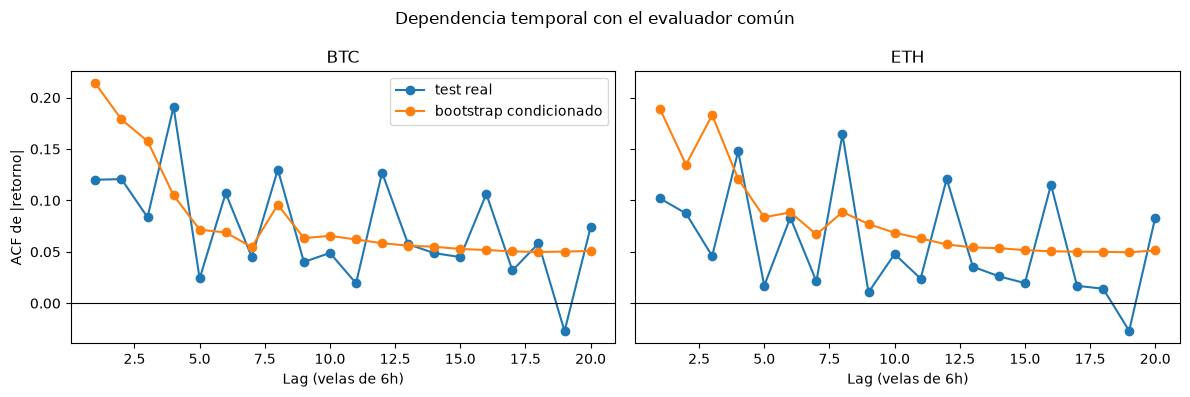

In [14]:
temporal_lags = np.arange(1, temporal_config.max_lag + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for axis, asset in zip(axes, ('BTC', 'ETH')):
    asset_report = temporal_report.by_asset[asset]
    axis.plot(
        temporal_lags,
        asset_report.reference.absolute_return_acf,
        marker='o',
        label='test real',
    )
    axis.plot(
        temporal_lags,
        asset_report.candidate.absolute_return_acf,
        marker='o',
        label='bootstrap condicionado',
    )
    axis.axhline(0, color='black', linewidth=0.8)
    axis.set(title=asset, xlabel='Lag (velas de 6h)')
axes[0].set_ylabel('ACF de |retorno|')
axes[0].legend()
fig.suptitle('Dependencia temporal con el evaluador común')
fig.tight_layout()

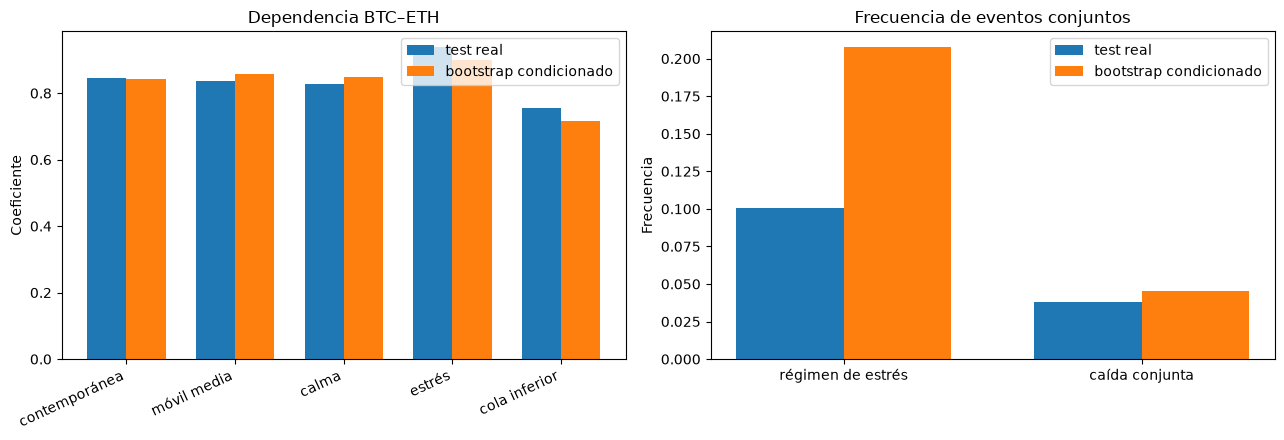

In [15]:
dependence_labels = [
    'contemporánea',
    'móvil media',
    'calma',
    'estrés',
    'cola inferior',
]
reference_dependence = [
    cross_asset_report.reference.contemporaneous_correlation,
    cross_asset_report.reference.rolling_correlation.mean,
    cross_asset_report.reference.calm_correlation,
    cross_asset_report.reference.stress_correlation,
    cross_asset_report.reference.lower_tail_dependence,
]
candidate_dependence = [
    cross_asset_report.candidate.contemporaneous_correlation,
    cross_asset_report.candidate.rolling_correlation.mean,
    cross_asset_report.candidate.calm_correlation,
    cross_asset_report.candidate.stress_correlation,
    cross_asset_report.candidate.lower_tail_dependence,
]

x_positions = np.arange(len(dependence_labels))
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(x_positions - 0.18, reference_dependence, 0.36, label='test real')
axes[0].bar(x_positions + 0.18, candidate_dependence, 0.36, label='bootstrap condicionado')
axes[0].set_xticks(x_positions, dependence_labels, rotation=25, ha='right')
axes[0].set(title='Dependencia BTC–ETH', ylabel='Coeficiente')
axes[0].legend()

event_labels = ['régimen de estrés', 'caída conjunta']
reference_events = [
    cross_asset_report.reference.stress_frequency,
    cross_asset_report.reference.joint_drop_probability,
]
candidate_events = [
    cross_asset_report.candidate.stress_frequency,
    cross_asset_report.candidate.joint_drop_probability,
]
event_positions = np.arange(len(event_labels))
axes[1].bar(event_positions - 0.18, reference_events, 0.36, label='test real')
axes[1].bar(event_positions + 0.18, candidate_events, 0.36, label='bootstrap condicionado')
axes[1].set_xticks(event_positions, event_labels)
axes[1].set(title='Frecuencia de eventos conjuntos', ylabel='Frecuencia')
axes[1].legend()
fig.tight_layout()

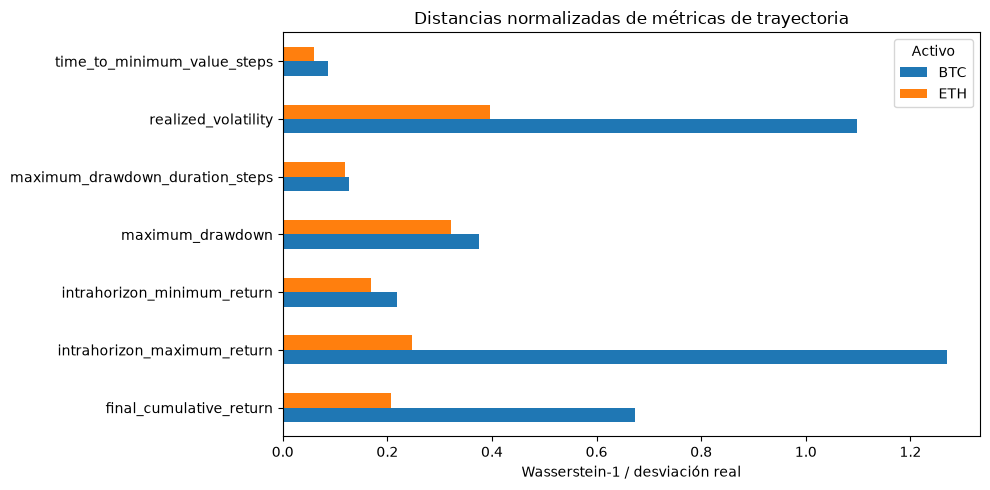

In [16]:
trajectory_distance_table = trajectory_table.pivot(
    index='metric',
    columns='asset',
    values='normalized_wasserstein_1',
)
axis = trajectory_distance_table.plot.barh(
    figsize=(10, 5),
    title='Distancias normalizadas de métricas de trayectoria',
)
axis.set(xlabel='Wasserstein-1 / desviación real', ylabel='')
axis.legend(title='Activo')
axis.figure.tight_layout()

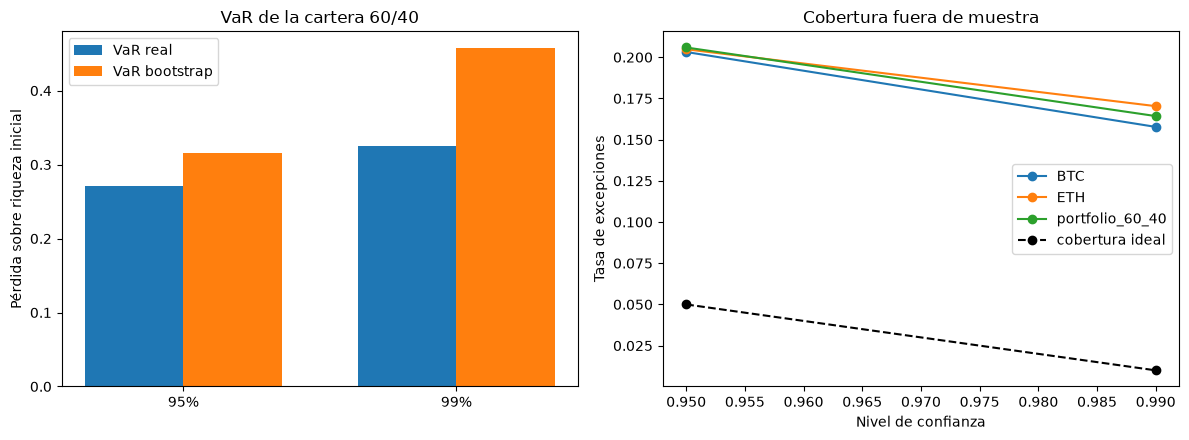

In [17]:
portfolio_risk = risk_table.loc[risk_table['target'].eq('portfolio_60_40')]
risk_positions = np.arange(len(portfolio_risk))
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(
    risk_positions - 0.18,
    portfolio_risk['reference_unconditional_var'],
    0.36,
    label='VaR real',
)
axes[0].bar(
    risk_positions + 0.18,
    portfolio_risk['candidate_unconditional_var'],
    0.36,
    label='VaR bootstrap',
)
axes[0].set_xticks(
    risk_positions,
    [f'{level:.0%}' for level in portfolio_risk['confidence_level']],
)
axes[0].set(title='VaR de la cartera 60/40', ylabel='Pérdida sobre riqueza inicial')
axes[0].legend()

for target, target_table in risk_table.groupby('target', sort=False):
    axes[1].plot(
        target_table['confidence_level'],
        target_table['exception_rate'],
        marker='o',
        label=target,
    )
axes[1].plot(
    portfolio_risk['confidence_level'],
    portfolio_risk['expected_exception_rate'],
    color='black',
    linestyle='--',
    marker='o',
    label='cobertura ideal',
)
axes[1].set(
    title='Cobertura fuera de muestra',
    xlabel='Nivel de confianza',
    ylabel='Tasa de excepciones',
)
axes[1].legend()
fig.tight_layout()

### Interpretación de riesgo

La tabla anterior debe interpretarse después de reejecutar el notebook. Las cifras del baseline incondicional se han eliminado porque ya no describen este modelo. Conviene revisar si el condicionamiento mejora simultáneamente cobertura y estabilidad del ES, y no solo una de ellas.

Los resultados siguen siendo descriptivos: las ventanas de test se solapan y no deben interpretarse como un backtest clásico con observaciones independientes.

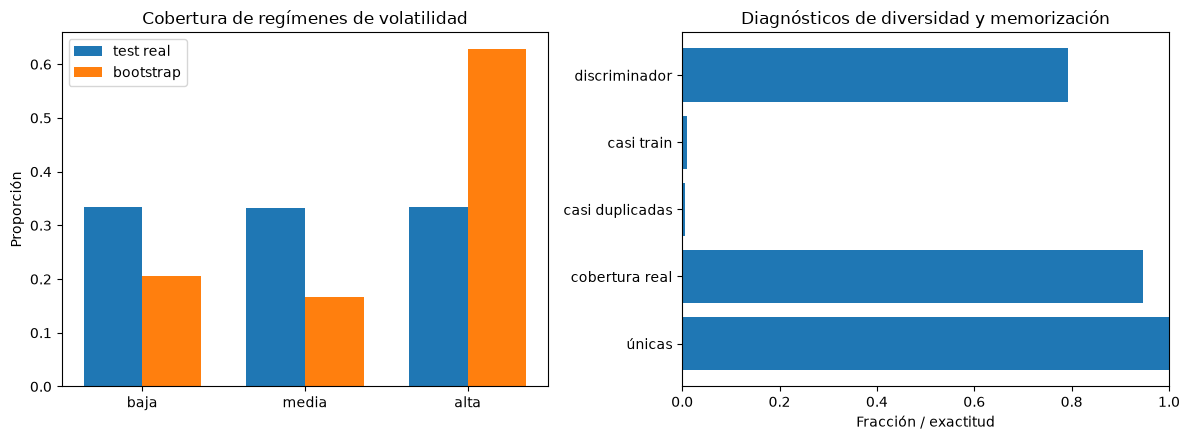

In [18]:
regime_names = ['low', 'medium', 'high']
regime_positions = np.arange(len(regime_names))
reference_regimes = [
    diversity_report.reference_regime_proportions[name]
    for name in regime_names
]
candidate_regimes = [
    diversity_report.candidate_regime_proportions[name]
    for name in regime_names
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(regime_positions - 0.18, reference_regimes, 0.36, label='test real')
axes[0].bar(regime_positions + 0.18, candidate_regimes, 0.36, label='bootstrap')
axes[0].set_xticks(regime_positions, ['baja', 'media', 'alta'])
axes[0].set(title='Cobertura de regímenes de volatilidad', ylabel='Proporción')
axes[0].legend()

diagnostic_names = [
    'únicas',
    'cobertura real',
    'casi duplicadas',
    'casi train',
    'discriminador',
]
diagnostic_values = [
    diversity_report.candidate_unique_fraction,
    diversity_report.reference_coverage_fraction,
    diversity_report.candidate_near_duplicate_fraction,
    diversity_report.near_memorization_fraction,
    diversity_report.discriminator_accuracy_mean,
]
axes[1].barh(diagnostic_names, diagnostic_values)
axes[1].set(
    title='Diagnósticos de diversidad y memorización',
    xlabel='Fracción / exactitud',
    xlim=(0, 1),
)
fig.tight_layout()

### Interpretación de diversidad y memorización

La tabla y las gráficas anteriores deben recalcularse. El vecindario introduce un compromiso nuevo: cuanto menor sea, mayor puede ser la fidelidad al régimen, pero también el riesgo de casi memorización.

Diversidad no equivale a fidelidad. Deben examinarse conjuntamente la cobertura de regímenes, la fracción de vecinos casi memorizados y la capacidad del discriminador para separar real de sintético.

### Control de sensibilidad con objetivos no solapados

Repetimos el mismo control del CVAE: conservamos una trayectoria real de test cada 120 ventanas, de modo que sus horizontes de 30 días no se solapan. Solo quedan 16 anclas, por lo que esta tabla es una comprobación de sensibilidad y no una estimación precisa de colas o eventos extremos.

Para igualar el presupuesto del control del CVAE generamos 320 escenarios nuevos (16 × 20). Cada grupo de 20 queda ahora vinculado explícitamente a la condición de su ancla. Evaluamos únicamente marginales y métricas de trayectoria, igual que en el CVAE.

In [19]:
NON_OVERLAPPING_SCENARIOS_PER_ANCHOR = 20
non_overlapping_positions = np.arange(0, len(test_targets), HORIZON_STEPS)
non_overlapping_reference = test_targets[non_overlapping_positions]
assert len(non_overlapping_reference) == 16

non_overlapping_conditions = np.repeat(
    test_conditions[non_overlapping_positions],
    NON_OVERLAPPING_SCENARIOS_PER_ANCHOR,
    axis=0,
)
non_overlapping_bootstrap = ConditionalMultivariateBlockBootstrap(
    block_length=SELECTED_BLOCK_LENGTH,
    n_neighbors=SELECTED_NEIGHBORS,
    random_state=SEED + 5_001,
).fit(training_targets, train_conditions)
non_overlapping_candidate = non_overlapping_bootstrap.sample(
    n_scenarios=(
        len(non_overlapping_reference)
        * NON_OVERLAPPING_SCENARIOS_PER_ANCHOR
    ),
    cond=non_overlapping_conditions,
    horizon_steps=HORIZON_STEPS,
)

non_overlapping_marginal_report = common_evaluator.evaluate_marginals(
    reference_paths=non_overlapping_reference,
    candidate_paths=non_overlapping_candidate,
)
non_overlapping_trajectory_report = common_evaluator.evaluate_trajectories(
    reference_paths=non_overlapping_reference,
    candidate_paths=non_overlapping_candidate,
    config=TrajectoryMetricsConfig(periods_per_year=4 * 365),
)

print('Anclas no solapadas:', len(non_overlapping_reference))
print('Escenarios bootstrap nuevos:', len(non_overlapping_candidate))
display(
    pd.DataFrame(non_overlapping_marginal_report.to_records())[[
        'asset',
        'normalized_wasserstein_1',
    ]].rename(
        columns={'normalized_wasserstein_1': 'W1 marginal normalizada'},
    )
)
pd.DataFrame(non_overlapping_trajectory_report.to_records()).pivot(
    index='metric',
    columns='asset',
    values='normalized_wasserstein_1',
).rename_axis(columns=None)

Anclas no solapadas: 16
Escenarios bootstrap nuevos: 320


,asset,W1 marginal normalizada
0,BTC,0.122012
1,ETH,0.056111


,BTC,ETH
metric,,
final_cumulative_return,0.753050,0.369381
intrahorizon_maximum_return,0.949924,0.232753
intrahorizon_minimum_return,0.582823,0.455635
maximum_drawdown,0.620265,0.445495
maximum_drawdown_duration_steps,0.446646,0.347241
realized_volatility,0.933892,0.209684
time_to_minimum_value_steps,0.219220,0.253364
